# ECE 3715 Mini-Project 1

**Team number: 0**  
**Step 1: Sample space and axioms**

Step 1 analyzes a four-bit packet with independent bit errors. The sample space is enumerated,
event probabilities are calculated, and the exact results are compared with a simulation of 1,000,000 packets.

My team number will be **0**.

The differences are reported as as estimate minus theory and use SE to mean standard error.


In [ ]:
from time import perf_counter
START = perf_counter()
from pathlib import Path
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from mp1lib import (bsc, packet_errors, attempts_until_clean, tv_distance,
                    probability_comparison)

TEAM_NUMBER = 0
SEED = TEAM_NUMBER
rng = np.random.default_rng(SEED)
rng1 = rng.spawn(1)[0]
rng2 = rng.spawn(1)[0]
rng3 = rng.spawn(1)[0]
rng4 = rng.spawn(1)[0]
rng5 = rng.spawn(1)[0]
rng6 = rng.spawn(1)[0]
rng7 = rng.spawn(1)[0]
rng8 = rng.spawn(1)[0]
rngA = rng.spawn(1)[0]
rngB = rng.spawn(1)[0]
rng_test = rng.spawn(1)[0]
print(f"Team: {TEAM_NUMBER}; seed: {SEED}")
print(f"Python {sys.version.split()[0]}, NumPy {np.__version__}, Matplotlib {matplotlib.__version__}")
FIGDIR = Path('figures')
FIGDIR.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 115, 'savefig.dpi': 160, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': .22, 'axes.spines.top': False})

def table(headers, rows):
    """Display a readable table without adding a dataframe dependency."""
    def fmt(x):
        return f'{x:.7g}' if isinstance(x, (float, np.floating)) else str(x).replace('|', r'\|')
    display(Markdown('| ' + ' | '.join(fmt(h) for h in headers) + ' |\n|' + '|'.join(['---']*len(headers)) + '|\n' +
                     '\n'.join('| ' + ' | '.join(fmt(x) for x in row) + ' |' for row in rows)))

def finish(fig, name):
    """Save a figure and display it exactly once."""
    fig.savefig(FIGDIR / f'{name}.png', bbox_inches='tight')
    plt.show()
    plt.close(fig)

CMP = ['Quantity', 'Estimate', 'Theory', 'Difference', 'SE', 'Difference/SE']

### Library function tests
The BSC is checked at p=0 and p=1, where every bit must be preserved or flipped. 
Packet error counts are verified at these same endpoints and ensure that
q=1 gives exactly one transmission attempt. For total variation distance, identical 
PMFs give zero and disjoint point masses give one.


In [ ]:
bits = np.array([[0, 1], [1, 0]], dtype=np.uint8)
assert np.array_equal(bsc(bits, 0, rng_test), bits)
assert np.array_equal(bsc(bits, 1, rng_test), 1-bits)
assert np.array_equal(packet_errors(3, 4, 0, rng_test), [0, 0, 0])
assert np.array_equal(packet_errors(3, 4, 1, rng_test), [4, 4, 4])
assert np.array_equal(attempts_until_clean(3, 1, rng_test), [1, 1, 1])
assert tv_distance([.25, .75], [.25, .75]) == 0.0
assert tv_distance([1, 0], [0, 1]) == 1.0
assert probability_comparison([0, 1], .5)[:3] == [.5, .5, 0]
print('All four library function tests passed.')


## Step 1 — Sample space and axioms

Error pattern is represented as $(e_1,e_2,e_3,e_4)$, where 1 means an error.

Independence gives

&emsp;&emsp;$P(e)=p^{k}(1-p)^{4-k},\qquad k=\sum_i e_i.$

The total probability is

&emsp;&emsp;$\sum_{k=0}^{4}{4\choose k}p^k(1-p)^{4-k}=(p+1-p)^4=1.$

At $p=0.1$, the individual event probabilities are

&emsp;&emsp;$P(A)=1-(0.9)^2=0.19,$

&emsp;&emsp;$P(B)={4\choose2}(0.1)^2(0.9)^2=0.0486,$

&emsp;&emsp;$P(C)=0.1.$

For $A\cap B$, five of the six two-error patterns qualify (all except 0011).

For $B\cap C$, one of the other three positions is chosen. For the triple intersection, the other error must be in position 1 or 2.

Therefore,

&emsp;&emsp;$P(A\cap B)=5(0.1)^2(0.9)^2=0.0405,$

&emsp;&emsp;$P(A\cap C)=P(A)P(C)=0.019,$

&emsp;&emsp;$P(B\cap C)=3(0.1)^2(0.9)^2=0.0243,$

&emsp;&emsp;$P(A\cap B\cap C)=2(0.1)^2(0.9)^2=0.0162.$

Inclusion-exclusion gives

&emsp;&emsp;$P(A\cup B\cup C)=0.19+0.0486+0.1-0.0405-0.019-0.0243+0.0162=0.2710.$

For a Bernoulli event of probability $\theta$,

&emsp;&emsp;$\operatorname{SE}(\hat{\theta})=\sqrt{\frac{\theta(1-\theta)}{N}}.$

At $N=10^6$, this is at most $0.0005$.

Each event's exact $\theta$ is used, including intersections and the union.


Exact sample-space mass = 0.9999999999999999


| Pattern | Exact probability | MC probability | Difference | SE |
|---|---|---|---|---|
| 0000 | 0.6561 | 0.656833 | 0.000733 | 0.0004750082 |
| 0001 | 0.0729 | 0.072507 | -0.000393 | 0.0002599723 |
| 0010 | 0.0729 | 0.072978 | 7.8e-05 | 0.0002599723 |
| 0011 | 0.0081 | 0.008221 | 0.000121 | 8.963476e-05 |
| 0100 | 0.0729 | 0.072779 | -0.000121 | 0.0002599723 |
| 0101 | 0.0081 | 0.008063 | -3.7e-05 | 8.963476e-05 |
| 0110 | 0.0081 | 0.008129 | 2.9e-05 | 8.963476e-05 |
| 0111 | 0.0009 | 0.000896 | -4e-06 | 2.99865e-05 |
| 1000 | 0.0729 | 0.072461 | -0.000439 | 0.0002599723 |
| 1001 | 0.0081 | 0.008113 | 1.3e-05 | 8.963476e-05 |
| 1010 | 0.0081 | 0.008122 | 2.2e-05 | 8.963476e-05 |
| 1011 | 0.0009 | 0.000922 | 2.2e-05 | 2.99865e-05 |
| 1100 | 0.0081 | 0.00816 | 6e-05 | 8.963476e-05 |
| 1101 | 0.0009 | 0.000868 | -3.2e-05 | 2.99865e-05 |
| 1110 | 0.0009 | 0.000846 | -5.4e-05 | 2.99865e-05 |
| 1111 | 0.0001 | 0.000102 | 2e-06 | 9.9995e-06 |

| Quantity | Estimate | Theory | Difference | SE | Difference/SE |
|---|---|---|---|---|---|
| A | 0.189461 | 0.19 | -0.000539 | 0.0003923009 | -1.373945 |
| B | 0.048808 | 0.0486 | 0.000208 | 0.0002150303 | 0.9673054 |
| C | 0.099692 | 0.1 | -0.000308 | 0.0003 | -1.026667 |
| A ∩ B | 0.040587 | 0.0405 | 8.7e-05 | 0.0001971288 | 0.4413359 |
| A ∩ C | 0.018964 | 0.019 | -3.6e-05 | 0.0001365247 | -0.2636885 |
| B ∩ C | 0.024397 | 0.0243 | 9.7e-05 | 0.0001539789 | 0.6299563 |
| A ∩ B ∩ C | 0.016176 | 0.0162 | -2.4e-05 | 0.000126244 | -0.190108 |
| A ∪ B ∪ C | 0.270189 | 0.271 | -0.000811 | 0.0004444761 | -1.82462 |

Empirical inclusion-exclusion = 0.2701890; direct union = 0.2701890
All seven event differences and union within 3 SE: True
Maximum event |difference|/SE = 1.8246
All 16 pattern differences within 3 SE: True; maximum |z|=1.8008


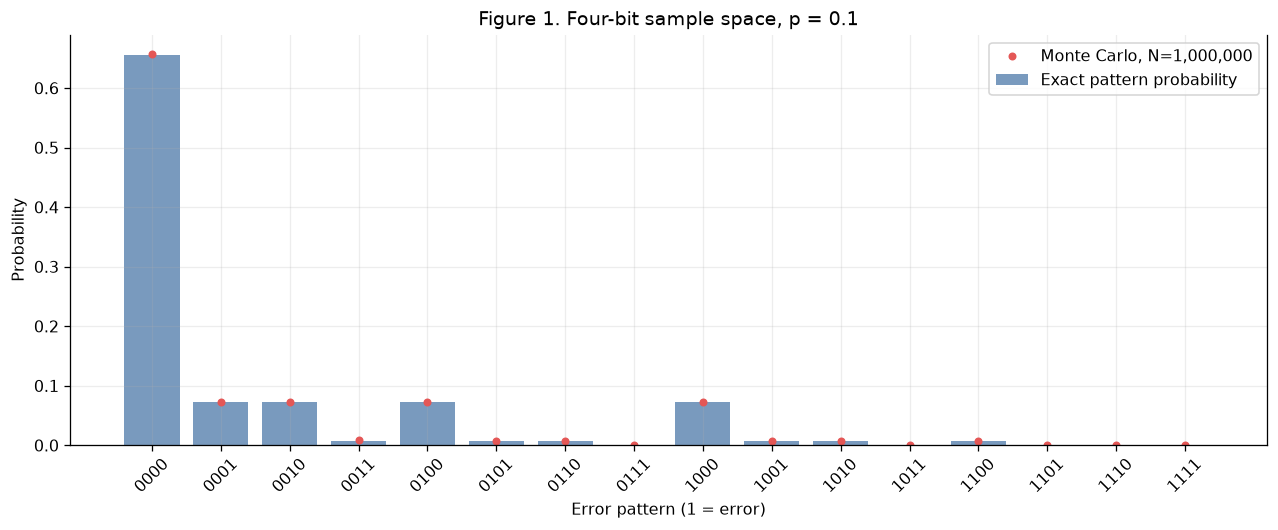

In [ ]:
p1, N1 = .1, 10**6
patterns = ((np.arange(16)[:, None] >> np.arange(3, -1, -1)) & 1).astype(np.uint8)
weights = p1**patterns.sum(axis=1) * (1-p1)**(4-patterns.sum(axis=1))
errors1 = bsc(np.zeros((N1, 4), dtype=np.uint8), p1, rng1)
observed = np.bincount(errors1 @ np.array([8, 4, 2, 1]), minlength=16)/N1
labels = [''.join(map(str, row)) for row in patterns]
print(f'Exact sample-space mass = {weights.sum():.16f}')
table(['Pattern', 'Exact probability', 'MC probability', 'Difference', 'SE'],
      [[label, w, e, e-w, np.sqrt(w*(1-w)/N1)] for label,w,e in zip(labels,weights,observed)])
a, b, c = errors1[:, :2].any(axis=1), errors1.sum(axis=1)==2, errors1[:, 3].astype(bool)
pa, pb, pc = patterns[:, :2].any(axis=1), patterns.sum(axis=1)==2, patterns[:, 3].astype(bool)
names1 = ['A', 'B', 'C', 'A ∩ B', 'A ∩ C', 'B ∩ C', 'A ∩ B ∩ C', 'A ∪ B ∪ C']
masks1 = [a,b,c,a&b,a&c,b&c,a&b&c,a|b|c]
exact_masks1 = [pa,pb,pc,pa&pb,pa&pc,pb&pc,pa&pb&pc,pa|pb|pc]
rows1 = [[name]+probability_comparison(mask, weights[exact_mask].sum())
         for name,mask,exact_mask in zip(names1,masks1,exact_masks1)]
table(CMP, rows1)
emp_ie = a.mean()+b.mean()+c.mean()-(a&b).mean()-(a&c).mean()-(b&c).mean()+(a&b&c).mean()
assert np.isclose(emp_ie, (a|b|c).mean())
assert np.allclose([r[2] for r in rows1], [.19,.0486,.1,.0405,.019,.0243,.0162,.271])
print(f'Empirical inclusion-exclusion = {emp_ie:.7f}; direct union = {(a|b|c).mean():.7f}')
print(f'All seven event differences and union within 3 SE: {all(abs(r[-1]) <= 3 for r in rows1)}')
print(f'Maximum event |difference|/SE = {max(abs(r[-1]) for r in rows1):.4f}')
pattern_z = (observed-weights)/np.sqrt(weights*(1-weights)/N1)
print(f'All 16 pattern differences within 3 SE: {np.all(np.abs(pattern_z)<=3)}; maximum |z|={np.max(np.abs(pattern_z)):.4f}')
fig, ax = plt.subplots(figsize=(11,4.5), layout='constrained')
ax.bar(labels, weights, color='#4c78a8', alpha=.75, label='Exact pattern probability')
ax.plot(labels, observed, 'o', color='#e45756', markersize=4, label='Monte Carlo, N=1,000,000')
ax.set(xlabel='Error pattern (1 = error)', ylabel='Probability', title='Figure 1. Four-bit sample space, p = 0.1')
ax.tick_params(axis='x', rotation=45)
ax.legend()
finish(fig, 'figure_01')
del errors1

The no-error pattern has probability $0.9^4=0.6561$, so it dominates the sample
space. For the union, an empirical probability of $0.270189$ is obtained, compared with the
exact value $0.2710$. The difference is $-0.000811$, or about $-1.825$ standard
errors with SE $0.000444476$.

In this seed-0 run, all seven event probabilities, the union, and all 16 pattern
probabilities are within three standard errors of their exact values. These
numerical checks are used to assess whether the system agrees rather than relying solely on the plotted markers.
The union is smaller than the sum $0.3386$ because the events overlap.

## Step 2 — Conditional probability and Bayes

Let $E$ be a bit error and $F$ a flag. The prior is $P(E)=p$, and the circuit has
$P(F\mid E)=0.95$ and $P(F\mid E^c)=0.02$.

The law of total probability gives the denominator

&emsp;&emsp;$P(F)=P(F\mid E)P(E)+P(F\mid E^c)P(E^c)$

&emsp;&emsp;$=0.95p+0.02(1-p)=0.02+0.93p.$

Bayes' rule then gives

&emsp;&emsp;$P(E\mid F)=\frac{P(F\mid E)P(E)}{P(F)}$

&emsp;&emsp;$=\frac{0.95p}{0.95p+0.02(1-p)}=\frac{0.95p}{0.02+0.93p}.$

For the crossover, set $P(E\mid F)=\frac12$. Then

&emsp;&emsp;$0.95p=\frac12(0.02+0.93p)$

&emsp;&emsp;$0.485p=0.01$

&emsp;&emsp;$p^*=\frac{0.01}{0.485}=0.0206.$

At $p^*$, the flag rate is

&emsp;&emsp;$P(F)=0.02+0.93p^*=0.0392,$

so $N=10^7$ bits should give about 391,000 flags.

The empirical posterior is $\hat r=n_{FE}/n_F$, where $n_F$ is the number of flags and $n_{FE}$ is the number
of flags on bits that are truly in error. Given $n_F$, each flag is a Bernoulli($r$) trial, so

&emsp;&emsp;$\operatorname{SE}(\hat r)=\sqrt{\frac{r(1-r)}{n_F}}$

with the exact $r=0.5$.


In [ ]:
TPR, FPR = .95, .02
post = lambda p: TPR*np.asarray(p) / (TPR*np.asarray(p) + FPR*(1-np.asarray(p)))
p2s = [.1, .01, .001]
table(['p', 'P(F)', 'Posterior'], [[p, TPR*p+FPR*(1-p), float(post(p))] for p in p2s])
assert np.isclose(post(.001), .0454, atol=5e-4)
pstar = .5*FPR / (TPR - .5*(TPR-FPR))
assert np.isclose(post(pstar), .5) and f'{pstar:.3g}' == '0.0206'
print(f'Crossover p* = {pstar:.6f} ({pstar:.3g} to three significant figures)')

N2 = 10**7
err2 = bsc(np.zeros(N2, dtype=np.uint8), pstar, rng2).astype(bool)
flag2 = rng2.random(N2) < np.where(err2, TPR, FPR)
nf, nfe = int(flag2.sum()), int((flag2 & err2).sum())
r_hat, pf = nfe/nf, TPR*pstar + FPR*(1-pstar)
se_r, se_f = np.sqrt(.25/nf), np.sqrt(pf*(1-pf)/N2)
print(f'Flags obtained = {nf:,} of {N2:,}; flagged and in error = {nfe:,}')
table(CMP, [['P(F)', nf/N2, pf, nf/N2-pf, se_f, (nf/N2-pf)/se_f],
            ['Posterior at p*', r_hat, .5, r_hat-.5, se_r, (r_hat-.5)/se_r]])
print(f'Both differences within 3 SE: {abs(nf/N2-pf) <= 3*se_f and abs(r_hat-.5) <= 3*se_r}')
del err2, flag2

pg = np.logspace(-4, -1, 200)
fig, ax = plt.subplots(figsize=(8,4.5), layout='constrained')
ax.semilogx(pg, post(pg), color='#4c78a8', label='Exact posterior')
ax.axvline(pstar, color='#f58518', ls='--', label=f'Crossover p* = {pstar:.3g}')
ax.errorbar([pstar], [r_hat], yerr=[se_r], fmt='o', color='#e45756', markersize=4, capsize=3,
            label='Monte Carlo, N=10,000,000')
ax.set(xlabel='Bit error probability p', ylabel='P(error | flag)', title='Figure 2. Posterior versus prior')
ax.legend()
finish(fig, 'figure_02')


The posterior is $0.0454$ at $p=0.001$, $0.324$ at $p=0.01$, and $0.841$ at $p=0.1$, and it equals
$0.5$ at $p^*=0.0206$. The simulation at $p^*$ gave $391{,}255$ flags, of which $195{,}406$ were true errors.
The empirical posterior is $0.499434$ compared with $0.5$, a difference of $-0.000566$, or
about $-0.708$ standard errors with SE $0.000799$. The flag rate is $0.0391255$ compared with
$0.0391753$, a difference of $-0.0000498$, or $-0.811$ standard errors with SE $0.0000614$.

A flag from a 95 percent accurate circuit means little on a good link because real errors are rare.
At $p=0.001$, only about $1$ in $1000$ bits is in error, but $2$ percent of the other $999$ are
still flagged, so about $955$ of every $1000$ flags are false alarms. The flag only becomes
trustworthy once errors are common enough that the real ones outnumber the false alarms.


## Step 3 — Independence

### Part 1 — Pairwise Independence vs. Mutual Independence

Flip two independent fair coins and define:

- $E_1$: the first coin lands heads.
- $E_2$: the second coin lands heads.
- $E_3$: the two coins match.

The sample space is

&emsp;&emsp;$\Omega=\{HH,HT,TH,TT\},$

where every outcome has probability $1/4$.

The individual probabilities are

&emsp;&emsp;$P(E_1)=P(E_2)=P(E_3)=\frac{1}{2}.$

For $E_1$ and $E_2$,

&emsp;&emsp;$P(E_1\cap E_2)=P(HH)=\frac{1}{4},$

while

&emsp;&emsp;$P(E_1)P(E_2)=\frac{1}{2}\cdot\frac{1}{2}=\frac{1}{4}.$

For $E_1$ and $E_3$,

&emsp;&emsp;$P(E_1\cap E_3)=P(HH)=\frac{1}{4},$

while

&emsp;&emsp;$P(E_1)P(E_3)=\frac{1}{2}\cdot\frac{1}{2}=\frac{1}{4}.$

For $E_2$ and $E_3$,

&emsp;&emsp;$P(E_2\cap E_3)=P(HH)=\frac{1}{4},$

while

&emsp;&emsp;$P(E_2)P(E_3)=\frac{1}{2}\cdot\frac{1}{2}=\frac{1}{4}.$

Therefore, all three pairs satisfy

&emsp;&emsp;$P(E_i\cap E_j)=P(E_i)P(E_j),$

so $E_1$, $E_2$, and $E_3$ are pairwise independent.

To test mutual independence,

&emsp;&emsp;$P(E_1\cap E_2\cap E_3)=P(HH)=\frac{1}{4}.$

However,

&emsp;&emsp;$P(E_1)P(E_2)P(E_3)=\left(\frac{1}{2}\right)^3=\frac{1}{8}.$

Since

&emsp;&emsp;$\frac{1}{4}\neq\frac{1}{8},$

the three events are pairwise independent but not mutually independent.


In [ ]:
# Step 3, Part 1: Pairwise independence versus mutual independence

N3 = 10**6

# Represent heads as 1 and tails as 0
coin1 = rng3.integers(0, 2, size=N3)
coin2 = rng3.integers(0, 2, size=N3)

# Define events
E1 = coin1 == 1
E2 = coin2 == 1
E3 = coin1 == coin2

# Individual probabilities
pE1 = np.mean(E1)
pE2 = np.mean(E2)
pE3 = np.mean(E3)

# Pairwise joint probabilities
pE1E2 = np.mean(E1 & E2)
pE1E3 = np.mean(E1 & E3)
pE2E3 = np.mean(E2 & E3)

# Triple joint probability
pE1E2E3 = np.mean(E1 & E2 & E3)

# Products of marginal probabilities
prodE1E2 = pE1 * pE2
prodE1E3 = pE1 * pE3
prodE2E3 = pE2 * pE3
prodE1E2E3 = pE1 * pE2 * pE3

print("Individual event probabilities:")
table(
    ["Event", "Estimate", "Exact"],
    [
        ["P(E1)", pE1, 0.5],
        ["P(E2)", pE2, 0.5],
        ["P(E3)", pE3, 0.5]
    ]
)

print("Pairwise and mutual independence comparisons:")
table(
    ["Comparison", "Joint Probability", "Product of Marginals", "Difference"],
    [
        ["E1 and E2", pE1E2, prodE1E2, pE1E2 - prodE1E2],
        ["E1 and E3", pE1E3, prodE1E3, pE1E3 - prodE1E3],
        ["E2 and E3", pE2E3, prodE2E3, pE2E3 - prodE2E3],
        ["E1 and E2 and E3", pE1E2E3, prodE1E2E3, pE1E2E3 - prodE1E2E3]
    ]
)

print(f"P(E1 and E2 and E3) ≈ {pE1E2E3:.6f}")
print(f"P(E1)P(E2)P(E3)   ≈ {prodE1E2E3:.6f}")


The numerical results confirm the analytical result.

For each pair of events, the estimated joint probability is approximately equal to the product of the estimated marginal probabilities. Each of these values should be close to

&emsp;&emsp;$0.25.$

This supports the conclusion that the events are pairwise independent.

For all three events together,

&emsp;&emsp;$P(E_1\cap E_2\cap E_3)\approx0.25,$

while

&emsp;&emsp;$P(E_1)P(E_2)P(E_3)\approx0.125.$

These values are clearly different, confirming that the three events are not mutually independent.

### Part 2 — Conditional Independence and a Common Cause

Let the transmitted bit be $X$, where

&emsp;&emsp;$P(X=0)=P(X=1)=\frac{1}{2}.$

Two receivers observe the transmitted bit through independent channels.

Receiver 1 has bit error probability

&emsp;&emsp;$p_1=0.1,$

and Receiver 2 has bit error probability

&emsp;&emsp;$p_2=0.3.$

Let $Y_1$ and $Y_2$ denote the outputs of the two receivers.

Although the errors introduced by the two channels are independent, both receiver outputs depend on the same transmitted bit $X$. Therefore, $X$ acts as a common cause that can make the receiver outputs dependent when the value of $X$ is not known.

The Pearson correlation coefficient is estimated for:

1. all $10^6$ transmissions,
2. the subset where $X=0$, and
3. the subset where $X=1$.

Conditioning on $X$ removes the shared source of variation, so the two conditional correlations are expected to be approximately zero.


In [ ]:
# Step 3, Part 2: Dependence caused by a shared transmitted bit

N3_part2 = 10**6

# Transmitted bit: equally likely to be 0 or 1
x = rng3.integers(0, 2, size=N3_part2)

# Independent channel errors
error1 = rng3.random(N3_part2) < 0.1
error2 = rng3.random(N3_part2) < 0.3

# Receiver outputs
y1 = np.bitwise_xor(x, error1.astype(np.uint8))
y2 = np.bitwise_xor(x, error2.astype(np.uint8))

# Unconditional correlation
r_all = np.corrcoef(y1, y2)[0, 1]

# Conditional subsets
mask_x0 = x == 0
mask_x1 = x == 1

r_x0 = np.corrcoef(y1[mask_x0], y2[mask_x0])[0, 1]
r_x1 = np.corrcoef(y1[mask_x1], y2[mask_x1])[0, 1]

# Number of samples
n_all = N3_part2
n_x0 = int(np.sum(mask_x0))
n_x1 = int(np.sum(mask_x1))

# Large-sample standard error for Pearson correlation
se_all = (1 - r_all**2) / np.sqrt(n_all - 3)
se_x0 = (1 - r_x0**2) / np.sqrt(n_x0 - 3)
se_x1 = (1 - r_x1**2) / np.sqrt(n_x1 - 3)

table(
    ["Condition", "Samples", "Correlation", "SE", "|Correlation| / SE"],
    [
        ["Unconditional", n_all, r_all, se_all, abs(r_all) / se_all],
        ["Given X = 0", n_x0, r_x0, se_x0, abs(r_x0) / se_x0],
        ["Given X = 1", n_x1, r_x1, se_x1, abs(r_x1) / se_x1]
    ]
)

print("Samples with X = 0:", f"{n_x0:,}")
print("Samples with X = 1:", f"{n_x1:,}")
print(
    "Both conditional subsets contain at least 100,000 samples:",
    n_x0 >= 100_000 and n_x1 >= 100_000
)

print()
print(f"Unconditional correlation = {r_all:.6f}, SE = {se_all:.6f}")
print(f"Correlation given X = 0 = {r_x0:.6f}, SE = {se_x0:.6f}")
print(f"Correlation given X = 1 = {r_x1:.6f}, SE = {se_x1:.6f}")


The unconditional receiver outputs are dependent because both $Y_1$ and $Y_2$ depend on the same transmitted bit $X$. The shared transmitted bit therefore acts as a common cause.

When the value of $X$ is fixed, that common source of variation is removed. The only remaining randomness comes from the two independent channel errors. As a result, the estimated correlations conditioned on $X=0$ and $X=1$ should both be approximately zero within sampling error.

The unconditional correlation should be noticeably different from zero, while the two conditional correlations should be small relative to their standard errors. This demonstrates that two variables can be dependent because of a shared cause even though they become independent after conditioning on that cause.

A system that fuses two sensor readings while assuming they are independent, when they actually share a common cause, can overestimate the amount of independent information available and become overconfident in the fused result.
